# Import necessary libraries

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from sklearn.metrics import mean_squared_error
colo_pal = sns.color_palette()
plt.style.use('fivethirtyeight')
from math import sqrt

# pip install xgboost==1.6.2


### Data loading

In [181]:
# # Data loading
# df1 = pd.read_csv('../data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv')
# df2 = pd.read_excel('../data/ForecastDataset_from_2023_to_2025_for_all_SKUs.xlsx')

In [182]:
import pandas as pd

# Define the common columns
cols = ["OrderDate", "Order_ID", "SKU", "WareHouseQuantity"]

# Load only common columns
df1 = pd.read_csv(
    "../data/ForecastDataset_from_2016_To_2024_for_all_SKUs.csv",
    usecols=cols
)
df2 = pd.read_excel(
    "../data/ForecastDataset_from_2023_to_2025_for_all_SKUs.xlsx",
    usecols=cols
)

# Combine
combined = pd.concat([df1, df2], ignore_index=True)

# Convert OrderDate to datetime
combined["OrderDate"] = pd.to_datetime(combined["OrderDate"], errors="coerce")

# Drop duplicates based on OrderDate + Order_ID + SKU
combined = combined.drop_duplicates(subset=["OrderDate", "Order_ID", "SKU"])

# Sort by date for time-series analysis
combined = combined.sort_values(by="OrderDate")

# Save merged file
# combined.to_csv("../data/ForecastDataset_2016_to_2025_Merged.csv", index=False)

print("Final dataset shape:", combined.shape)


Final dataset shape: (1570037, 4)


In [183]:
df = combined.copy()

In [185]:
df.head(-1)

,Order_ID,OrderDate,WareHouseQuantity,SKU
0,54522457,2016-12-23,1.0,90AD01AD01
1,54526264,2016-12-28,1.0,90AD01AD01
2,54536438,2016-12-30,1.0,90AD01AD01
51,54537032,2016-12-31,1.0,90AD01AD01
50,54536615,2016-12-31,1.0,90AD01AD01
...,...,...,...,...
1541514,688851,2025-07-17,1.0,10AD550GRF02
1541515,688851,2025-07-17,NaN,CereTax
1541516,689752,2025-07-17,NaN,CereTax
1541517,689181,2025-07-17,1.0,10AD200GRF01


In [187]:
df.nunique()

Order_ID             1019610
OrderDate               3092
WareHouseQuantity         27
SKU                      153
dtype: int64

In [188]:
# Check numeric columns variance
numeric_variance = df.var(numeric_only=True)   #Only numeric columns
print("Variance of numeric columns:\n", numeric_variance)

Variance of numeric columns:
 Order_ID             8.884010e+14
WareHouseQuantity    2.811043e-01
dtype: float64


In [189]:
df.shape

(1570037, 4)

In [190]:
df.isna().sum()

Order_ID                 0
OrderDate                0
WareHouseQuantity    80914
SKU                  17504
dtype: int64

In [191]:
df.nunique()

Order_ID             1019610
OrderDate               3092
WareHouseQuantity         27
SKU                      153
dtype: int64

In [192]:
df.isna().sum()

Order_ID                 0
OrderDate                0
WareHouseQuantity    80914
SKU                  17504
dtype: int64

In [193]:
df.dropna(inplace=True)

In [194]:
df.shape

(1471619, 4)

### Take a subset of features (Because we want weekly forecast by sku)

In [195]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'], format="%m/%d/%Y", errors='coerce')
df = df.dropna(subset=['OrderDate', 'SKU', 'WareHouseQuantity']).copy()

In [196]:
## Keep relevant cols
df = df[['OrderDate', 'SKU', 'WareHouseQuantity']].copy()


In [197]:
df

,OrderDate,SKU,WareHouseQuantity
0,2016-12-23,90AD01AD01,1.0
1,2016-12-28,90AD01AD01,1.0
2,2016-12-30,90AD01AD01,1.0
51,2016-12-31,90AD01AD01,1.0
50,2016-12-31,90AD01AD01,1.0
...,...,...,...
1541512,2025-07-17,10AD200GRF01,1.0
1541513,2025-07-17,10AD200GRF01,2.0
1541514,2025-07-17,10AD550GRF02,1.0
1541517,2025-07-17,10AD200GRF01,1.0


### Weekly aggregation per SKU

Example:

If OrderDate = 2023-09-07 (Thursday)
 - EndWeek = 2023-09-10 (Sunday)
 - StartWeek = 2023-09-04 (Monday)

So weekly periods will always be `Monday → Sunday.`

In [198]:
import pandas as pd

# Ensure OrderDate is datetime
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

# WeekEnd = Sunday of that week
df["WeekEnd"] = df["OrderDate"] + pd.to_timedelta((6 - df["OrderDate"].dt.weekday) % 7, unit="D")

# WeekStart = Monday before that Sunday
df["WeekStart"] = df["WeekEnd"] - pd.Timedelta(days=6)

# Aggregate weekly per SKU
weekly = (
    df.groupby(["SKU", "WeekStart", "WeekEnd"], as_index=False)
      .agg(WareHouseQuantity=("WareHouseQuantity", "sum"))
)

# Sort by WeekStart (time order)
weekly = weekly.sort_values(by="WeekStart").reset_index(drop=True)

print(weekly.head(40))


             SKU  WeekStart    WeekEnd  WareHouseQuantity
0     90AD01AD01 2016-12-19 2016-12-25                1.0
1     90AD01AD01 2016-12-26 2017-01-01              127.0
2     90AD01AD01 2017-01-02 2017-01-08              127.0
3     90AD01AD01 2017-01-09 2017-01-15              294.0
4     90AD01AD01 2017-01-16 2017-01-22               47.0
5     90AD01AD01 2017-01-23 2017-01-29              192.0
6     90AD01AD01 2017-01-30 2017-02-05               55.0
7   10AD300GRF01 2017-01-30 2017-02-05                2.0
8   10AD300HRF01 2017-01-30 2017-02-05                2.0
9     90AD01AD01 2017-02-06 2017-02-12               28.0
10    90AD01AD01 2017-02-13 2017-02-19               10.0
11    90AD01AD01 2017-02-20 2017-02-26                5.0
12    90AD01AD01 2017-02-27 2017-03-05                3.0
13    90AD01AD01 2017-03-06 2017-03-12                4.0
14    90AD01AD01 2017-03-13 2017-03-19                3.0
15    90AD01AD01 2017-03-20 2017-03-26                2.0
16    90AD01AD

In [199]:
print("Earliest week start date:", weekly["WeekStart"].min())
print("Latest week start date:", weekly["WeekStart"].max())
weekly.sort_values("WeekStart").head(20)

Earliest week start date: 2016-12-19 00:00:00
Latest week start date: 2025-07-14 00:00:00


,SKU,WeekStart,WeekEnd,WareHouseQuantity
0,90AD01AD01,2016-12-19,2016-12-25,1.0
1,90AD01AD01,2016-12-26,2017-01-01,127.0
2,90AD01AD01,2017-01-02,2017-01-08,127.0
3,90AD01AD01,2017-01-09,2017-01-15,294.0
4,90AD01AD01,2017-01-16,2017-01-22,47.0
5,90AD01AD01,2017-01-23,2017-01-29,192.0
7,10AD300GRF01,2017-01-30,2017-02-05,2.0
8,10AD300HRF01,2017-01-30,2017-02-05,2.0
6,90AD01AD01,2017-01-30,2017-02-05,55.0
9,90AD01AD01,2017-02-06,2017-02-12,28.0


In [200]:
weekly

,SKU,WeekStart,WeekEnd,WareHouseQuantity
0,90AD01AD01,2016-12-19,2016-12-25,1.0
1,90AD01AD01,2016-12-26,2017-01-01,127.0
2,90AD01AD01,2017-01-02,2017-01-08,127.0
3,90AD01AD01,2017-01-09,2017-01-15,294.0
4,90AD01AD01,2017-01-16,2017-01-22,47.0
...,...,...,...,...
10625,10AD300HRF01,2025-07-14,2025-07-20,69.0
10626,10AD200CMPK1,2025-07-14,2025-07-20,230.0
10627,90AD01AT01-W,2025-07-14,2025-07-20,35.0
10628,40AD02WC301,2025-07-14,2025-07-20,2.0


### SKU Activity → Forecastability

Filter only those skus which are forecastable

In [201]:
# 3) SKU Activity → Forecastability
# =========================
latest_date = df['OrderDate'].max()

sku_activity = df.groupby("SKU").agg(
    StartDate=("OrderDate", "min"),
    EndDate=("OrderDate", "max"),
    # TotalOrders=("Order_ID", "count"),
    TotalQuantity=("WareHouseQuantity", "sum")
).reset_index()

sku_activity["ActiveDays"] = (sku_activity["EndDate"] - sku_activity["StartDate"]).dt.days
sku_activity["Status"] = sku_activity["EndDate"].apply(
    lambda x: "Inactive" if (latest_date - x).days > 90 else "Active"
)
sku_activity["Forecastability"] = sku_activity.apply(
    lambda row: (
        "Forecastable" if (row["Status"] == "Active" and row["ActiveDays"] >= 365)
        else ("Not Forecastable" if row["Status"] == "Active" else "Inactive")
    ),
    axis=1
)

forecastable_skus = sku_activity.loc[sku_activity["Forecastability"] == "Forecastable", "SKU"].unique()
print(f"Forecastable SKUs: {len(forecastable_skus)}")

Forecastable SKUs: 73


### Filtering only forecastable SKUs

In [202]:
weekly_filtered = weekly[weekly['SKU'].isin(forecastable_skus)].copy()

In [203]:
weekly_filtered.head(-1)

,SKU,WeekStart,WeekEnd,WareHouseQuantity
7,10AD300GRF01,2017-01-30,2017-02-05,2.0
8,10AD300HRF01,2017-01-30,2017-02-05,2.0
17,40AD01WC301,2017-03-27,2017-04-02,1.0
19,10AD300GRF01,2017-04-10,2017-04-16,105.0
21,10AD300HRF01,2017-04-10,2017-04-16,8.0
...,...,...,...,...
10624,30AD500CMPK1,2025-07-14,2025-07-20,7.0
10625,10AD300HRF01,2025-07-14,2025-07-20,69.0
10626,10AD200CMPK1,2025-07-14,2025-07-20,230.0
10627,90AD01AT01-W,2025-07-14,2025-07-20,35.0


In [204]:
weekly_filtered

,SKU,WeekStart,WeekEnd,WareHouseQuantity
7,10AD300GRF01,2017-01-30,2017-02-05,2.0
8,10AD300HRF01,2017-01-30,2017-02-05,2.0
17,40AD01WC301,2017-03-27,2017-04-02,1.0
19,10AD300GRF01,2017-04-10,2017-04-16,105.0
21,10AD300HRF01,2017-04-10,2017-04-16,8.0
...,...,...,...,...
10625,10AD300HRF01,2025-07-14,2025-07-20,69.0
10626,10AD200CMPK1,2025-07-14,2025-07-20,230.0
10627,90AD01AT01-W,2025-07-14,2025-07-20,35.0
10628,40AD02WC301,2025-07-14,2025-07-20,2.0


In [205]:
weekly_filtered.columns

Index(['SKU', 'WeekStart', 'WeekEnd', 'WareHouseQuantity'], dtype='object')

In [206]:
weekly_filtered["SKU"].unique()
len(weekly_filtered["SKU"].unique())

73

### Continuous Weekly Series (Making Weeks Continuous)

If any SKU has a missing week in between (e.g., jumps from Feb 20 → Mar 06), DeepAR will not work correctly. That’s why we reindex with a complete weekly range per SKU.

Example: 
Start_Week: `20 Feb 2024 - 06 Mar 2024`




In [207]:
import pandas as pd

def make_continuous_weekly(df):
    all_data = []

    for sku, g in df.groupby("SKU"):
        # Ensure sorted by WeekStart
        g = g.sort_values("WeekStart")

        # Full weekly range between min and max
        full_range = pd.date_range(
            g["WeekStart"].min(),
            g["WeekStart"].max(),
            freq="W-MON"  # align to Mondays (same as your WeekStart)
        )

        # Reindex to continuous weeks
        g = g.set_index("WeekStart").reindex(full_range)

        # Fill SKU column
        g["SKU"] = sku

        # Fill missing quantities with 0 (or ffill/interpolate if business logic requires)
        g["WareHouseQuantity"] = g["WareHouseQuantity"].fillna(0)

        # Recompute WeekEnd (Sunday of that week)
        g["WeekEnd"] = g.index + pd.Timedelta(days=6)

        # Reset index
        g = g.reset_index().rename(columns={"index": "WeekStart"})

        all_data.append(g)

    result = pd.concat(all_data).reset_index(drop=True)

    result = result.sort_values("WeekStart").reset_index(drop=True)

    return result


# Apply to your forecastable SKUs dataset
weekly_continuous = make_continuous_weekly(weekly_filtered)

weekly_continuous


,WeekStart,SKU,WeekEnd,WareHouseQuantity
0,2017-01-30,10AD300HRF01,2017-02-05,2.0
1,2017-01-30,10AD300GRF01,2017-02-05,2.0
2,2017-02-06,10AD300GRF01,2017-02-12,0.0
3,2017-02-06,10AD300HRF01,2017-02-12,0.0
4,2017-02-13,10AD300GRF01,2017-02-19,0.0
...,...,...,...,...
11146,2025-07-14,10AD350CMPK1,2025-07-20,715.0
11147,2025-07-14,30AD02CMPK2,2025-07-20,124.0
11148,2025-07-14,10AD01FND02,2025-07-20,3.0
11149,2025-07-14,30AD500CMPK1,2025-07-20,7.0


In [208]:
weekly_continuous.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11151 entries, 0 to 11150
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   WeekStart          11151 non-null  datetime64[ns]
 1   SKU                11151 non-null  object        
 2   WeekEnd            11151 non-null  datetime64[ns]
 3   WareHouseQuantity  11151 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(1)
memory usage: 348.6+ KB


In [209]:
# !pip install --upgrade pip setuptools wheel
# !pip install torch
# !pip install "gluonts[torch]"


### DeepAR

In [26]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator

# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
# Allowlist StudentTOutput so Lightning can reload checkpoints safely.
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),  # canonical
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),   # some builds reference this path
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

# Also allowlist NegativeLogLikelihood for PyTorch 2.6+ checkpoint loading
try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data (just in case)
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length based on the shortest training series
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],   # global model uses SKU embedding
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)  # ensure enough history
    ],
    freq=FREQ,
)

# Test: full history (evaluation compares the last pred_len points)
test_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + 1)
    ],
    freq=FREQ,
)

# Safety: ensure datasets are not empty
def _count(ds):
    return sum(1 for _ in ds)
_train_n = _count(train_ds)
_test_n  = _count(test_ds)
if _train_n == 0 or _test_n == 0:
    raise RuntimeError(f"Empty dataset(s): train={_train_n}, test={_test_n}. "
                       f"Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
# Keep arguments conservative & API-compatible across gluonts[torch] releases
estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    # static-cat embedding (global model across SKUs)
    cardinality=cardinality,
    # Model capacity (these are supported in torch DeepAR)
    hidden_size=64,
    num_layers=2,
    dropout_rate=0.1,
    # Lightning trainer args go here:
    trainer_kwargs={
        "max_epochs": 20,
        "accelerator": "auto",   # "gpu" if you have CUDA, else CPU
        "devices": 1,
        "log_every_n_steps": 10,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True
        
        # "enable_checkpointing": False,
    },
)

# -----------------------------
# 4) Train
# -----------------------------
predictor = estimator.train(training_data=train_ds)
print(f" Trained global DeepAR on {_train_n} SKUs; prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# Example: show one SKU’s forecast mean
print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\json.py:101: UserWarning: Using `json`-module for json-handling. Consider installing one of `orjson`, `ujson` to speed up serialization and deserialization.
  warnings.warn(
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\s

 Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 457.93it/s]


 Aggregate metrics:
                 MSE: 13217.745183
           abs_error: 2110.869470
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.590163
                MAPE: 5.332757
               sMAPE: 1.453006
                MSIS: 15.396118
   QuantileLoss[0.1]: 1642.035427
       Coverage[0.1]: 0.425000
   QuantileLoss[0.5]: 2110.869470
       Coverage[0.5]: 0.650000
   QuantileLoss[0.9]: 706.660247
       Coverage[0.9]: 0.700000
                RMSE: 114.968453
               NRMSE: 10.062884
                  ND: 4.618970
  wQuantileLoss[0.1]: 3.593075
  wQuantileLoss[0.5]: 4.618970
  wQuantileLoss[0.9]: 1.546303
mean_absolute_QuantileLoss: 1486.521715
  mean_wQuantileLoss: 3.252783
        MAE_Coverage: 0.333333
                 OWA: nan

Example forecast mean (first series):
[0.1505565]


In [28]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 20.00%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_15264\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,0,2,100.00,1,3,Out_of_Range
1,10AD01FNB02,2024-04-29,1,6,-5,-500.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,4,-2,-100.00,1,3,Out_of_Range
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,0,2,100.00,1,3,Out_of_Range
6,10AD01TF01,2024-04-29,117,439,-322,-275.21,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,134,-120,-857.14,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,426,-340,-395.35,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,88,-71,-417.65,15,19,Out_of_Range


In [29]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator

# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
# Allowlist StudentTOutput so Lightning can reload checkpoints safely.
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),  # canonical
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),   # some builds reference this path
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

# Also allowlist NegativeLogLikelihood for PyTorch 2.6+ checkpoint loading
try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data (just in case)
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length based on the shortest training series
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],   # global model uses SKU embedding
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)  # ensure enough history
    ],
    freq=FREQ,
)

# Test: full history (evaluation compares the last pred_len points)
test_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + 1)
    ],
    freq=FREQ,
)

# Safety: ensure datasets are not empty
def _count(ds):
    return sum(1 for _ in ds)
_train_n = _count(train_ds)
_test_n  = _count(test_ds)
if _train_n == 0 or _test_n == 0:
    raise RuntimeError(f"Empty dataset(s): train={_train_n}, test={_test_n}. "
                       f"Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
# Keep arguments conservative & API-compatible across gluonts[torch] releases
estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    # static-cat embedding (global model across SKUs)
    cardinality=cardinality,
    # Model capacity (these are supported in torch DeepAR)
    hidden_size=128,
    num_layers=2,
    # dropout_rate=0.1,
    lr=0.005,
    batch_size=256,
    
    # Lightning trainer args go here:
    trainer_kwargs={
        "max_epochs": 100,
        "accelerator": "auto",   # "gpu" if you have CUDA, else CPU
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True,
        
        # "enable_checkpointing": False,
    },
    num_batches_per_epoch=25,
)

# -----------------------------
# 4) Train
# -----------------------------
predictor = estimator.train(training_data=train_ds)
print(f" Trained global DeepAR on {_train_n} SKUs; prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# Example: show one SKU’s forecast mean
print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\trainer\configuration_validator.py:108: PossibleUserWarning: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
  rank_zero_warn(
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tens

 Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 560.91it/s]


 Aggregate metrics:
                 MSE: 9417.887395
           abs_error: 1769.677924
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.411420
                MAPE: 4.275309
               sMAPE: 1.388997
                MSIS: 13.421533
   QuantileLoss[0.1]: 1308.331787
       Coverage[0.1]: 0.450000
   QuantileLoss[0.5]: 1769.677924
       Coverage[0.5]: 0.625000
                RMSE: 97.045800
               NRMSE: 8.494162
                  ND: 3.872381
  wQuantileLoss[0.1]: 2.862870
  wQuantileLoss[0.5]: 3.872381
mean_absolute_QuantileLoss: 1539.004855
  mean_wQuantileLoss: 3.367626
        MAE_Coverage: 0.325000
                 OWA: nan

Example forecast mean (first series):
[1.6470321]


In [ ]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 22.50%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_2928\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,1,1,50.00,1,3,Acceptable
1,10AD01FNB02,2024-04-29,1,10,-9,-900.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,3,-1,-50.00,1,3,Acceptable
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,1,1,50.00,1,3,Acceptable
6,10AD01TF01,2024-04-29,117,473,-356,-304.27,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,54,-40,-285.71,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,426,-340,-395.35,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,94,-77,-452.94,15,19,Out_of_Range


### Using Early Stopping

In [30]:
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2024-01-31, forecast the weeks after
# With validation + early stopping
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import StudentTOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping


# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2024-01-31")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2024-01-31; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)
    ],
    freq=FREQ,
)

# Validation: full history, but GluonTS evaluates on the last pred_len windows
val_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + context_length)
    ],
    freq=FREQ,
)

# Test: full history (same as validation, can reuse later)
test_ds = val_ds

# Safety check
def _count(ds): return sum(1 for _ in ds)
if _count(train_ds) == 0 or _count(val_ds) == 0:
    raise RuntimeError("Empty train/val dataset. Check cutoff and data availability.")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min"
)

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=StudentTOutput(),
    cardinality=cardinality,
    hidden_size=128,
    num_layers=2,
    lr=0.001,
    batch_size=256,
    num_batches_per_epoch=20,
    trainer_kwargs={
        "max_epochs": 50,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": False,
        "deterministic": True,
        "callbacks": [early_stop],
    },
)

# -----------------------------
# 4) Train with validation
# -----------------------------
predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
print(f"Trained global DeepAR on {_count(train_ds)} SKUs; "
      f"prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=2,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

print("\nExample forecast mean (first series):")
print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\pytorch_lightning\callbacks\model_checkpoint.py:613: UserWarning: Checkpoint directory c:\forecasting\workspace2\forecasting\research_notebooks\checkpoints exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
c:\forecasting\workspace2\forecasting\.venv\Lib\site-packages\gluonts\torch\util.py:188: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:312.)
  return a[idx]

  | 

Trained global DeepAR on 40 SKUs; prediction_length=1, context_length=12


Running evaluation: 40it [00:00, 459.65it/s]


 Aggregate metrics:
                 MSE: 13362.723050
           abs_error: 1528.809825
      abs_target_sum: 457.000000
     abs_target_mean: 11.425000
      seasonal_error: 38.180265
                MASE: 1.448664
                MAPE: 4.589624
               sMAPE: 1.526292
                MSIS: 50.881014
   QuantileLoss[0.1]: 2611.521193
       Coverage[0.1]: 0.500000
   QuantileLoss[0.5]: 1528.809825
       Coverage[0.5]: 0.500000
                RMSE: 115.597245
               NRMSE: 10.117921
                  ND: 3.345317
  wQuantileLoss[0.1]: 5.714488
  wQuantileLoss[0.5]: 3.345317
mean_absolute_QuantileLoss: 2070.165509
  mean_wQuantileLoss: 4.529903
        MAE_Coverage: 0.200000
                 OWA: nan

Example forecast mean (first series):
[0.8376779]


In [31]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(pred)

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df


Business Accuracy (±10% rule): 27.50%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_15264\1697042201.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2024-03-04,2,1,1,50.00,1,3,Acceptable
1,10AD01FNB02,2024-04-29,1,8,-7,-700.00,0,2,Out_of_Range
2,10AD01FNC02,2024-04-01,2,8,-6,-300.00,1,3,Out_of_Range
3,10AD01FND02,2024-04-22,3,0,3,100.00,2,4,Out_of_Range
4,10AD01FNF02,2024-04-15,15,0,15,100.00,13,17,Out_of_Range
5,10AD01PC01,2024-04-15,2,2,0,0.00,1,3,Acceptable
6,10AD01TF01,2024-04-29,117,519,-402,-343.59,105,129,Out_of_Range
7,10AD02CMPK1,2024-04-29,14,105,-91,-650.00,12,16,Out_of_Range
8,10AD200CMPK1,2024-04-29,86,458,-372,-432.56,77,95,Out_of_Range
9,10AD200GRF01,2024-04-29,17,83,-66,-388.24,15,19,Out_of_Range


### DeepAR Final Results

In [243]:
%%capture output
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train ≤ 2025-05-01, forecast the weeks after
# With validation + early stopping
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import NegativeBinomialOutput   #  changed here
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.callbacks import Callback


# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# --------------------------------------------
# 0) PyTorch ≥ 2.6 safe-globals (fix ckpt load)
# --------------------------------------------
safe_classes = []
for mod_name, cls_name in [
    ("gluonts.torch.distributions.student_t", "StudentTOutput"),
    ("gluonts.torch.distributions.studentT", "StudentTOutput"),
    ("gluonts.torch.distributions.negative_binomial", "NegativeBinomialOutput"),
    ("gluonts.torch.distributions.negativeBinomial", "NegativeBinomialOutput"),
    ("gluonts.torch.distributions.poisson", "PoissonOutput"),  # optional, if you test Poisson later
]:
    try:
        mod = importlib.import_module(mod_name)
        safe_classes.append(getattr(mod, cls_name))
    except Exception:
        pass

try:
    from gluonts.torch.modules.loss import NegativeLogLikelihood
    safe_classes.append(NegativeLogLikelihood)
except Exception:
    pass

if hasattr(torch, "serialization") and hasattr(torch.serialization, "add_safe_globals") and safe_classes:
    torch.serialization.add_safe_globals(safe_classes)

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"
CUTOFF = pd.Timestamp("2025-05-01")  # train ≤ this date

# Weeks after cutoff per SKU (for horizon)
post_counts = (
    df.groupby("SKU")["WeekStart"]
      .apply(lambda s: (s > CUTOFF).sum())
      .astype(int)
)

# Keep only SKUs that have at least 1 post-cutoff week
eligible_skus = post_counts[post_counts > 0].index.tolist()
df = df[df["SKU"].isin(eligible_skus)]

# Common prediction length across all (use the minimum post-cutoff weeks so it fits everyone)
pred_len = int(post_counts.loc[eligible_skus].min())
if pred_len <= 0:
    raise ValueError("No SKU has data after 2025-05-01; cannot set prediction_length.")

# Compute shortest training length across eligible SKUs
train_lengths = (
    df[df["WeekStart"] <= CUTOFF]
      .groupby("SKU")["WeekStart"]
      .count()
)

# Filter out SKUs with no training data
eligible_skus = [sku for sku in eligible_skus if train_lengths.get(sku, 0) > 0]
df = df[df["SKU"].isin(eligible_skus)]
train_lengths = train_lengths.loc[eligible_skus]

# Set a safe global context_length
# how many past timesteps DeepAR will look at when making a prediction.
context_length = max(2, min(12, int(train_lengths.min()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: only up to cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g_train["WeekStart"].iloc[0],
            "target": g_train["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        for g_train in [g[g["WeekStart"] <= CUTOFF]]
        if len(g_train) >= max(3, context_length)
    ],
    freq=FREQ,
)

# Validation: full history, but GluonTS evaluates on the last pred_len windows
val_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + context_length)
    ],
    freq=FREQ,
)

# Test: full history (same as validation, can reuse later)
test_ds = val_ds

# Safety check
def _count(ds): return sum(1 for _ in ds)
if _count(train_ds) == 0 or _count(val_ds) == 0:
    raise RuntimeError("Empty train/val dataset. Check cutoff and data availability.")


class LossHistory(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        if "train_loss" in trainer.callback_metrics:
            self.train_losses.append(trainer.callback_metrics["train_loss"].item())
        else:
            self.train_losses.append(None)

    def on_validation_epoch_end(self, trainer, pl_module):
        if "val_loss" in trainer.callback_metrics:
            self.val_losses.append(trainer.callback_metrics["val_loss"].item())
        else:
            self.val_losses.append(None)

loss_history = LossHistory()

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,   # Training will stop if val_loss doesn't improve for 15 validation checks (epochs).
    mode="min"
)

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=NegativeBinomialOutput(),   #  non-negative distribution
    cardinality=cardinality,  # number of categories
    hidden_size=256,  # size of internal RNN hidden state
    num_layers=3,  # number of RNN layers
    lr=0.0001,
    batch_size=256,
    num_batches_per_epoch=20,
    trainer_kwargs={
        "max_epochs": 50,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": False,
        "logger": True,
        "deterministic": True,
        "callbacks": [early_stop, loss_history],
    },
)

# -----------------------------
# 4) Train with validation
# -----------------------------
# fits the model
predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
print(f"Trained global DeepAR on {_count(train_ds)} SKUs; "
      f"prediction_length={pred_len}, context_length={context_length}")

# -----------------------------
# 5) Forecast (evaluate on holdout)
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=100,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\n Aggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")

# print("\nExample forecast mean (first series):")
# print(forecasts[0].mean)


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | In sizes | Out sizes  
---------------------------------------------------------------
0 | model | DeepARModel | 1.3 M  | ?        | [1, 100, 3]
---------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.368     Total estimated model params size (MB)
Epoch 0, global step 20: 'val_loss' reached 8.15792 (best 8.15792), saving model to 'c:\\forecasting\\workspace2\\forecasting\\research_notebooks\\lightning_logs\\version_117\\checkpoints\\epoch=0-step=20.ckpt' as top 1
Epoch 1, global step 40: 'val_loss' reached 8.11366 (best 8.11366), saving model to 'c:\\forecasting\\workspace2\\forecasting\\research_notebooks\\lightning_logs\\version_117\\checkpoints\\epoch=1-step=40.ckpt' as top 1
Epoch 2, global step 60: 'val_loss' re

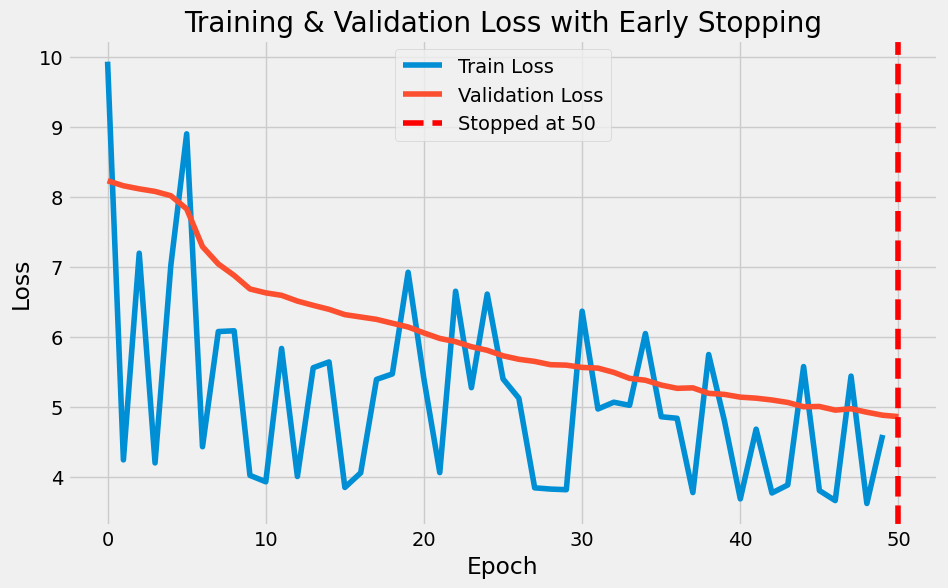

In [244]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(loss_history.train_losses, label="Train Loss")
plt.plot(loss_history.val_losses, label="Validation Loss")

# Mark the early stopping epoch (last logged val_loss)
stopped_epoch = len(loss_history.val_losses) - 1
plt.axvline(stopped_epoch, color="red", linestyle="--", label=f"Stopped at {stopped_epoch}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss with Early Stopping")
plt.legend()
plt.grid(True)
plt.show()


In [248]:
import math

# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id  
    
    actual_vals = ts.values[-pred_len:]
    pred_vals = np.round(fcst.mean).astype(int)   # force integer predictions
    
    # Convert PeriodIndex → Timestamp for week starts
    start_date = ts.index[-pred_len].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=pred_len, freq=FREQ)
    
    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(max(0, pred))

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan
        
        # compute tolerance ranges
        minus_10 = math.floor(actual * 0.9)
        plus_10  = math.ceil(actual * 1.1)
        
        # check if prediction is within range
        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# 7) Business Accuracy Calculation
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"Business Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
# print(results_df.head(20))
results_df.to_csv("DeepAR Results.csv")

results_df


Business Accuracy (±10% rule): 45.07%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_18912\824937134.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2025-06-30,14,16,-2,-14.29,12,16,Acceptable
1,10AD01FNA02,2025-07-07,9,13,-4,-44.44,8,10,Out_of_Range
2,10AD01FNA02,2025-07-14,11,11,0,0.00,9,13,Acceptable
3,10AD01FNB02,2025-06-30,23,12,11,47.83,20,26,Out_of_Range
4,10AD01FNB02,2025-07-07,12,12,0,0.00,10,14,Acceptable
...,...,...,...,...,...,...,...,...,...
208,90AD550AD01,2025-07-07,121,152,-31,-25.62,108,134,Out_of_Range
209,90AD550AD01,2025-07-14,67,127,-60,-89.55,60,74,Out_of_Range
210,90AD550SC01,2025-06-30,50,49,1,2.00,45,56,Acceptable
211,90AD550SC01,2025-07-07,30,40,-10,-33.33,27,33,Out_of_Range


In [249]:
results_df['Within_10_Percent'].value_counts()

Within_10_Percent
Out_of_Range    117
Acceptable       96
Name: count, dtype: int64

### Using 80/20 Split

In [252]:
%%capture output
# ============================================
# Global DeepAR (PyTorch) on weekly_continuous
# Train = first 80%, Forecast = last 20%
# With validation + early stopping
# ============================================

import pandas as pd
import numpy as np
import torch
import importlib
import random
import math

from gluonts.dataset.common import ListDataset
from gluonts.torch.model.deepar import DeepAREstimator
from gluonts.torch.distributions import NegativeBinomialOutput
from gluonts.evaluation.backtest import make_evaluation_predictions
from gluonts.evaluation import Evaluator
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.callbacks import Callback

# -----------------------------
# 0) Set seeds for reproducibility
# -----------------------------
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

class LossHistory(Callback):
    def __init__(self):
        self.train_losses = []
        self.val_losses = []

    def on_train_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None:
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())

loss_history = LossHistory()

# -----------------------------
# 1) Prepare data
# -----------------------------
assert {"SKU", "WeekStart", "WareHouseQuantity"}.issubset(weekly_continuous.columns), \
    "weekly_continuous must have columns: SKU, WeekStart, WareHouseQuantity"

df = weekly_continuous.copy()
df["WeekStart"] = pd.to_datetime(df["WeekStart"])
df = df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

FREQ = "W-MON"

# Compute per-SKU cutoff (80% train, 20% test)
cutoffs = {}
for sku, g in df.groupby("SKU"):
    n = len(g)
    if n < 5:   # skip very short series
        continue
    cutoff_idx = int(n * 0.8)
    cutoff_date = g["WeekStart"].iloc[cutoff_idx]
    cutoffs[sku] = cutoff_date

# Keep only SKUs that have enough history
eligible_skus = list(cutoffs.keys())
df = df[df["SKU"].isin(eligible_skus)]

# Compute prediction length = min(20% length across SKUs)
post_counts = {
    sku: (g["WeekStart"] > cutoffs[sku]).sum()
    for sku, g in df.groupby("SKU")
}
pred_len = min(post_counts.values())
if pred_len <= 0:
    raise ValueError("No SKU has enough test horizon for 80/20 split.")

# Context length = min training length - 1 (capped between 2 and 12)
train_lengths = {
    sku: (g["WeekStart"] <= cutoffs[sku]).sum()
    for sku, g in df.groupby("SKU")
}
context_length = max(2, min(12, min(train_lengths.values()) - 1))

# Map SKU → integer ID for static-cat embedding
sku_list = sorted(eligible_skus)
sku_to_idx = {sku: i for i, sku in enumerate(sku_list)}
cardinality = [len(sku_list)]

# -----------------------------
# 2) Build GluonTS datasets
# -----------------------------
# Training: up to 80% cutoff
train_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g[g["WeekStart"] <= cutoffs[sku]]["WeekStart"].iloc[0],
            "target": g[g["WeekStart"] <= cutoffs[sku]]["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g[g["WeekStart"] <= cutoffs[sku]]) >= max(3, context_length)
    ],
    freq=FREQ,
)

# Validation/Test: full history (evaluation will use last pred_len steps)
val_ds = ListDataset(
    [
        {
            "item_id": sku,
            "start": g["WeekStart"].iloc[0],
            "target": g["WareHouseQuantity"].to_numpy(dtype=float),
            "feat_static_cat": [sku_to_idx[sku]],
        }
        for sku, g in df.groupby("SKU")
        if len(g) >= (pred_len + context_length)
    ],
    freq=FREQ,
)

test_ds = val_ds

# Safety check
def _count(ds): return sum(1 for _ in ds)
if _count(train_ds) == 0 or _count(val_ds) == 0:
    raise RuntimeError("Empty train/val dataset. Check 80/20 split and data availability.")

print(f"SKUs in dataset: {len(sku_list)}")
print(f"Train series: {_count(train_ds)}, Val/Test series: {_count(val_ds)}")
print(f"Prediction length: {pred_len}, Context length: {context_length}")

# -----------------------------
# 3) Define global DeepAR
# -----------------------------
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    mode="min"
)

estimator = DeepAREstimator(
    freq=FREQ,
    prediction_length=pred_len,
    context_length=context_length,
    distr_output=NegativeBinomialOutput(),
    cardinality=cardinality,
    hidden_size=256,
    num_layers=3,
    lr=0.0001,
    batch_size=256,
    num_batches_per_epoch=50,
    trainer_kwargs={
        "max_epochs": 500,
        "accelerator": "auto",
        "devices": 1,
        "log_every_n_steps": 50,
        "enable_progress_bar": True,
        "logger": False,
        "deterministic": True,
        "callbacks": [early_stop, loss_history],
    },
)

# -----------------------------
# 4) Train with validation
# -----------------------------
predictor = estimator.train(training_data=train_ds, validation_data=val_ds)
print(f"Trained DeepAR on {_count(train_ds)} SKUs (80/20 split).")

# -----------------------------
# 5) Forecast on holdout
# -----------------------------
forecast_it, ts_it = make_evaluation_predictions(
    dataset=test_ds,
    predictor=predictor,
    num_samples=300,
)

forecasts = list(forecast_it)
tss = list(ts_it)

# -----------------------------
# 6) Evaluate
# -----------------------------
evaluator = Evaluator(quantiles=[0.1, 0.5, 0.9])
agg_metrics, item_metrics = evaluator(iter(tss), iter(forecasts))

print("\nAggregate metrics:")
for k, v in agg_metrics.items():
    if isinstance(v, (int, float)):
        print(f"{k:>20s}: {v:.6f}")



GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs

  | Name  | Type        | Params | In sizes | Out sizes   
----------------------------------------------------------------
0 | model | DeepARModel | 1.3 M  | ?        | [1, 100, 10]
----------------------------------------------------------------
1.3 M     Trainable params
0         Non-trainable params
1.3 M     Total params
5.368     Total estimated model params size (MB)
Epoch 0, global step 50: 'val_loss' reached 6.06647 (best 6.06647), saving model to 'c:\\forecasting\\workspace2\\forecasting\\research_notebooks\\checkpoints\\epoch=0-step=50.ckpt' as top 1
Epoch 1, global step 100: 'val_loss' reached 5.33257 (best 5.33257), saving model to 'c:\\forecasting\\workspace2\\forecasting\\research_notebooks\\checkpoints\\epoch=1-step=100.ckpt' as top 1
Epoch 2, global step 150: 'val_loss' reached 5.04878 (best 5.04878), saving model to 'c:\\

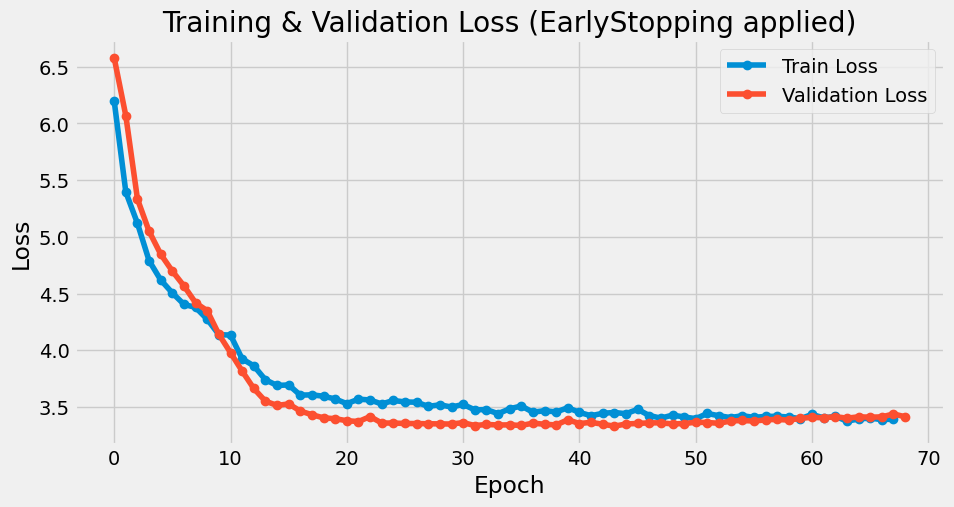

In [178]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(loss_history.train_losses, label="Train Loss", marker="o")
plt.plot(loss_history.val_losses, label="Validation Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss (EarlyStopping applied)")
plt.legend()
plt.grid(True)
plt.show()


In [179]:
# -----------------------------
# 7) Build Results DataFrame
# -----------------------------
results = []

for ts, fcst in zip(tss, forecasts):
    sku = fcst.item_id
    cutoff_date = cutoffs[sku]

    # Convert cutoff_date → Period for comparison
    cutoff_period = pd.Period(cutoff_date, freq=FREQ)

    # Actual values (20% test portion)
    actual_vals = ts[ts.index > cutoff_period].values
    pred_vals = np.round(fcst.mean).astype(int)[:len(actual_vals)]

    # Align dates
    start_date = ts[ts.index > cutoff_period].index[0].to_timestamp()
    week_starts = pd.date_range(start=start_date, periods=len(actual_vals), freq=FREQ)

    for wk, actual, pred in zip(week_starts, actual_vals, pred_vals):
        actual = int(actual)
        pred = int(max(0, pred))

        diff = actual - pred
        pct_diff = (diff / actual) * 100 if actual != 0 else np.nan

        minus_10 = math.floor(actual * 0.9)
        plus_10 = math.ceil(actual * 1.1)

        status = "Acceptable" if minus_10 <= pred <= plus_10 else "Out_of_Range"

        results.append({
            "SKU": sku,
            "WeekStart": wk,
            "Actual_WareHouseQuantity": actual,
            "Predicted_WareHouseQuantity": pred,
            "Difference_Between_Predicted_And_Actual": diff,
            "Percent_Difference": round(pct_diff, 2) if not np.isnan(pct_diff) else None,
            "Minus_10_Percent": minus_10,
            "Plus_10_Percent": plus_10,
            "Within_10_Percent": status
        })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(["SKU", "WeekStart"]).reset_index(drop=True)

# -----------------------------
# 8) Business Accuracy
# -----------------------------
business_accuracy = (results_df["Within_10_Percent"] == "Acceptable").mean() * 100
print(f"\nBusiness Accuracy (±10% rule): {business_accuracy:.2f}%")

print("\nSample of results DataFrame:")
results_df



Business Accuracy (±10% rule): 19.18%

Sample of results DataFrame:


C:\Users\Nilam Wadhavane\AppData\Local\Temp\ipykernel_18912\1073721689.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  actual = int(actual)


,SKU,WeekStart,Actual_WareHouseQuantity,Predicted_WareHouseQuantity,Difference_Between_Predicted_And_Actual,Percent_Difference,Minus_10_Percent,Plus_10_Percent,Within_10_Percent
0,10AD01FNA02,2025-01-27,19,13,6,31.58,17,21,Out_of_Range
1,10AD01FNA02,2025-02-03,6,14,-8,-133.33,5,7,Out_of_Range
2,10AD01FNA02,2025-02-10,2,15,-13,-650.00,1,3,Out_of_Range
3,10AD01FNA02,2025-02-17,11,15,-4,-36.36,9,13,Out_of_Range
4,10AD01FNA02,2025-02-24,15,14,1,6.67,13,17,Acceptable
...,...,...,...,...,...,...,...,...,...
725,90AD550SC01,2025-04-07,67,63,4,5.97,60,74,Acceptable
726,90AD550SC01,2025-04-14,47,60,-13,-27.66,42,52,Out_of_Range
727,90AD550SC01,2025-04-21,56,53,3,5.36,50,62,Acceptable
728,90AD550SC01,2025-04-28,36,47,-11,-30.56,32,40,Out_of_Range
